# 机器学习算法实践 02：KNN 分类算法从零实现——基于理化特征的葡萄酒分类

## 实验目的

本实验以 Wine 葡萄酒数据集为例，从零实现 K 近邻（K-Nearest Neighbors，KNN）分类算法。

通过本实验理解 KNN 算法的基本思想，掌握欧氏距离、最近邻搜索和多数投票等核心步骤，并研究 K 值以及特征尺度对 KNN 分类结果的影响。

实验首先使用 Python 和 NumPy 手写 KNN 分类算法，然后通过数据标准化研究不同特征尺度对距离计算的影响，最后使用 scikit-learn 中的 KNeighborsClassifier 进行对比验证。

## 1. KNN 算法原理

KNN（K-Nearest Neighbors，K 近邻）是一种基于样本之间距离进行分类的机器学习算法。

对于一个待分类样本，KNN 的基本步骤如下：

1. 计算待分类样本与训练集中所有样本之间的距离；
2. 将所有训练样本按照距离从小到大排序；
3. 选择距离最近的 K 个样本；
4. 统计这 K 个样本所属的类别；
5. 根据多数投票原则，将出现次数最多的类别作为预测结果。

例如，当 K=5 时，距离待分类样本最近的 5 个训练样本类别分别为：

`类别0、类别0、类别1、类别0、类别1`

其中类别0出现 3 次，类别1出现 2 次，因此最终将该样本预测为类别0。

### 1.1 欧氏距离

本实验使用欧氏距离衡量两个样本之间的相似程度。

对于两个 n 维样本：

$$
x=(x_1,x_2,\ldots,x_n)
$$

$$
y=(y_1,y_2,\ldots,y_n)
$$

它们之间的欧氏距离为：

$$
d(x,y)=\sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}
$$

两个样本之间的欧氏距离越小，说明它们在特征空间中的位置越接近。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("环境准备完成！")

环境准备完成！


## 2. Wine 数据集

本实验使用 scikit-learn 内置的 Wine 葡萄酒数据集。

该数据集包含不同类别葡萄酒的理化分析结果。机器学习任务是根据葡萄酒的各项理化特征，判断葡萄酒所属的类别。

In [3]:
wine = load_wine()

X = wine.data
y = wine.target

print("特征数据 X 的形状：", X.shape)
print("标签数据 y 的形状：", y.shape)

print("\n类别名称：")
print(wine.target_names)

print("\n特征名称：")
for feature in wine.feature_names:
    print(feature)

特征数据 X 的形状： (178, 13)
标签数据 y 的形状： (178,)

类别名称：
['class_0' 'class_1' 'class_2']

特征名称：
alcohol
malic_acid
ash
alcalinity_of_ash
magnesium
total_phenols
flavanoids
nonflavanoid_phenols
proanthocyanins
color_intensity
hue
od280/od315_of_diluted_wines
proline


In [6]:
#数据转化为dataframe
df = pd.DataFrame(
    X,
    columns=wine.feature_names
)

df["target"] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
print("数据集大小：", df.shape)

print("\n各类别样本数量：")
print(df["target"].value_counts().sort_index())

print("\n缺失值数量：")
print(df.isnull().sum())

数据集大小： (178, 14)

各类别样本数量：
target
0    59
1    71
2    48
Name: count, dtype: int64

缺失值数量：
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


In [7]:
#统计特征
df[wine.feature_names].describe().T[
    ["min", "max", "mean", "std"]
]

,min,max,mean,std
alcohol,11.03,14.83,13.000618,0.811827
malic_acid,0.74,5.80,2.336348,1.117146
ash,1.36,3.23,2.366517,0.274344
alcalinity_of_ash,10.60,30.00,19.494944,3.339564
magnesium,70.00,162.00,99.741573,14.282484
total_phenols,0.98,3.88,2.295112,0.625851
flavanoids,0.34,5.08,2.029270,0.998859
nonflavanoid_phenols,0.13,0.66,0.361854,0.124453
proanthocyanins,0.41,3.58,1.590899,0.572359
color_intensity,1.28,13.00,5.058090,2.318286


### 2.1 特征尺度问题

Wine 数据集中的不同特征具有不同的数值范围。

例如，部分特征的数值只有个位数或十几，而部分特征的数值可能达到几百甚至上千。

由于 KNN 依赖欧氏距离：

$$
d(x,y)=\sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}
$$

因此数值范围较大的特征可能在距离计算中占据更大的影响，从而影响 KNN 的分类结果。

后续实验将分别使用原始数据和标准化后的数据进行 KNN 分类，对比特征尺度对分类结果的影响。

In [8]:
#划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("训练集：", X_train.shape)
print("测试集：", X_test.shape)

训练集： (142, 13)
测试集： (36, 13)


## 3. 从零实现 KNN

### 3.1 欧氏距离

KNN 首先需要计算待预测样本与训练样本之间的距离，因此首先实现欧氏距离函数。

In [10]:
#欧氏距离函数
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

x1 = np.array([1, 2])
x2 = np.array([4, 6])

distance = euclidean_distance(x1, x2)

print("欧氏距离：", distance)

欧氏距离： 5.0


### 3.2 KNN 单样本预测

对于一个待预测样本，依次计算其与所有训练样本之间的距离，并选择距离最近的 K 个训练样本。

然后统计这 K 个样本的类别，通过多数投票得到最终预测结果。

In [11]:
def knn_predict(X_train, y_train, x, k=3):
    distances = []

    # 计算待预测样本与每个训练样本之间的距离
    for i in range(len(X_train)):
        distance = euclidean_distance(x, X_train[i])
        distances.append(distance)

    # 对距离排序，并取得距离最近的 K 个样本索引
    nearest_indices = np.argsort(distances)[:k]

    # 获取最近 K 个样本的类别
    nearest_labels = y_train[nearest_indices]

    # 多数投票
    counts = np.bincount(nearest_labels)

    # 返回出现次数最多的类别
    prediction = np.argmax(counts)

    return prediction

In [13]:
#预测一个葡萄酒样本
x = X_test[0]

prediction = knn_predict(
    X_train,
    y_train,
    x,
    k=3
)

# print("真实类别：", y_test[0])
# print("预测类别：", prediction)
print("真实类别：", wine.target_names[y_test[0]])
print("预测类别：", wine.target_names[prediction])

真实类别： class_0
预测类别： class_0


In [15]:
#预测整个测试集
def knn_predict_all(X_train, y_train, X_test, k=3):
    predictions = []

    for x in X_test:
        prediction = knn_predict(
            X_train,
            y_train,
            x,
            k
        )

        predictions.append(prediction)

    return np.array(predictions)

y_pred_original = knn_predict_all(
    X_train,
    y_train,
    X_test,
    k=3
)

accuracy_original = accuracy_score(
    y_test,
    y_pred_original
)

print(f"原始数据 KNN 准确率：{accuracy_original:.2%}")

原始数据 KNN 准确率：75.00%


## 4. 特征标准化

由于 Wine 数据集中不同特征的数值范围差异较大，直接计算欧氏距离可能导致数值范围较大的特征对距离产生更大的影响。

因此，本实验使用标准化方法对特征进行处理：

$$
z=\frac{x-\mu}{\sigma}
$$

其中：

- $x$ 表示原始特征值；
- $\mu$ 表示该特征的平均值；
- $\sigma$ 表示该特征的标准差。

标准化后，各特征具有相近的数据尺度，可以减少不同量纲对欧氏距离计算的影响。

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
#标准化以后再跑一次手写 KNN
y_pred_scaled = knn_predict_all(
    X_train_scaled,
    y_train,
    X_test_scaled,
    k=3
)

accuracy_scaled = accuracy_score(
    y_test,
    y_pred_scaled
)

print(f"标准化前准确率：{accuracy_original:.2%}")
print(f"标准化后准确率：{accuracy_scaled:.2%}")

标准化前准确率：75.00%
标准化后准确率：97.22%


## 5. K 值对分类结果的影响

K 是 KNN 算法中的一个重要超参数，表示进行分类时所参考的最近邻样本数量。

当 K 较小时，分类结果主要由少量邻近样本决定，因此容易受到局部样本或噪声的影响；随着 K 增大，模型会综合更多邻近样本的信息，分类结果通常更加稳定。但 K 过大时，也可能引入距离较远的其他类别样本，从而影响分类效果。

为了研究 K 值对模型性能的影响，本实验在标准化后的数据上分别设置 K=1～20，并比较不同 K 值对应的分类准确率。

In [18]:
#研究不同 K 值
k_values = range(1, 21)

accuracies = []

for k in k_values:
    predictions = knn_predict_all(
        X_train_scaled,
        y_train,
        X_test_scaled,
        k=k
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    accuracies.append(accuracy)

for k, accuracy in zip(k_values, accuracies):
    print(f"K={k:2d}, Accuracy={accuracy:.2%}")

K= 1, Accuracy=97.22%
K= 2, Accuracy=94.44%
K= 3, Accuracy=97.22%
K= 4, Accuracy=94.44%
K= 5, Accuracy=97.22%
K= 6, Accuracy=97.22%
K= 7, Accuracy=100.00%
K= 8, Accuracy=100.00%
K= 9, Accuracy=100.00%
K=10, Accuracy=100.00%
K=11, Accuracy=100.00%
K=12, Accuracy=100.00%
K=13, Accuracy=100.00%
K=14, Accuracy=97.22%
K=15, Accuracy=100.00%
K=16, Accuracy=100.00%
K=17, Accuracy=100.00%
K=18, Accuracy=97.22%
K=19, Accuracy=100.00%
K=20, Accuracy=100.00%


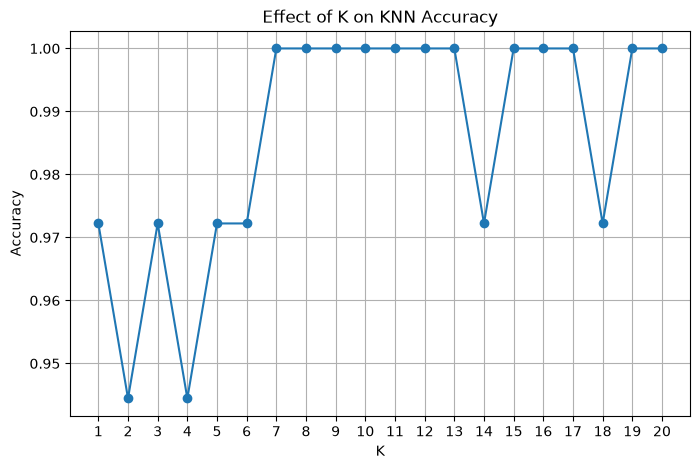

In [19]:
#画 K-Accuracy 曲线
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Effect of K on KNN Accuracy")

plt.xticks(k_values)
plt.grid()

plt.show()

In [20]:
#找一下准确率最高的 K
best_index = np.argmax(accuracies)

best_k = list(k_values)[best_index]
best_accuracy = accuracies[best_index]

print("最佳 K 值：", best_k)
print(f"最高准确率：{best_accuracy:.2%}")

最佳 K 值： 7
最高准确率：100.00%


In [24]:
#混淆矩阵和分类报告
y_pred_best = knn_predict_all(
    X_train_scaled,
    y_train,
    X_test_scaled,
    k=best_k
)


cm = confusion_matrix(
    y_test,
    y_pred_best
)

cm_df = pd.DataFrame(
    cm,
    index=wine.target_names,
    columns=wine.target_names
)

display(cm_df)



print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=wine.target_names
    )
)

,class_0,class_1,class_2
class_0,12,0,0
class_1,0,14,0
class_2,0,0,10


              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## 6. sklearn KNN 对比实验

为了验证手写 KNN 算法的实现是否正确，使用 scikit-learn 中的 `KNeighborsClassifier` 在相同的数据集上进行实验。

sklearn 模型使用与手写 KNN 相同的训练集、测试集、标准化方式和 K 值，并比较两种实现的预测结果。

In [26]:
sklearn_knn = KNeighborsClassifier(
    n_neighbors=best_k
)

sklearn_knn.fit(
    X_train_scaled,
    y_train
)

sklearn_pred = sklearn_knn.predict(
    X_test_scaled
)

sklearn_accuracy = accuracy_score(
    y_test,
    sklearn_pred
)

print(f"手写 KNN 准确率：{best_accuracy:.2%}")
print(f"sklearn KNN 准确率：{sklearn_accuracy:.2%}")

手写 KNN 准确率：100.00%
sklearn KNN 准确率：100.00%


In [27]:
print(
    "两种方法预测结果是否完全一致：",
    np.array_equal(
        y_pred_best,
        sklearn_pred
    )
)

两种方法预测结果是否完全一致： True


## 7. 实验结果分析

### 7.1 特征标准化对 KNN 的影响

在使用原始 Wine 数据进行 KNN 分类时，当 K=3 时模型准确率仅为 **75.00%**。对数据进行标准化后，在相同 K=3 的条件下，模型准确率提高到了 **97.22%**。

标准化前后准确率变化为：

| 数据处理方式 | K值 | Accuracy |
| --- | ---: | ---: |
| 原始数据 | 3 | 75.00% |
| 标准化数据 | 3 | 97.22% |

准确率提高了 **22.22 个百分点**。

产生这一现象的主要原因是 KNN 依赖样本之间的距离进行分类，而 Wine 数据集不同特征的数值范围存在较大差异。在原始数据中，数值范围较大的特征会在欧氏距离计算中产生更大的影响，从而削弱其他特征的作用。

经过标准化后，各个特征被转换到相近的数据尺度，使不同特征能够更加合理地参与距离计算，因此 KNN 的分类效果得到明显改善。

### 7.2 K 值对分类效果的影响

在标准化数据上进一步测试 K=1～20 时发现，不同 K 值对应的分类准确率存在一定差异。

其中：

- K=2 和 K=4 时，准确率最低，为 94.44%；
- K=1、3、5、6、14、18 时，准确率为 97.22%；
- K=7～13、15～17、19～20 时，准确率达到 100.00%。

实验中首次达到最高准确率的 K 值为 **K=7**，因此本实验选择 K=7 作为后续分析使用的参数。

实验结果说明，K 值会影响 KNN 的分类结果。K 较小时，模型更容易受到局部样本和噪声的影响；适当增加 K 可以综合更多邻近样本的信息，使分类结果更加稳定。但 K 并不是越大越好，在其他数据集或更大的取值范围中，过大的 K 可能引入距离较远的其他类别样本，从而降低模型的区分能力。

需要注意的是，本实验的测试集只有 36 个样本，因此多个 K 值取得 100% 测试准确率只能说明它们在本次数据划分下均正确分类了全部测试样本，并不能说明这些 K 值在所有未知数据上都能达到 100% 的分类准确率。

### 7.3 最佳 K 值下的分类结果

选择 K=7 后，手写 KNN 在 36 个测试样本上的准确率达到 **100.00%**。

混淆矩阵结果为：

| 真实类别 / 预测类别 | class_0 | class_1 | class_2 |
| --- | ---: | ---: | ---: |
| class_0 | 12 | 0 | 0 |
| class_1 | 0 | 14 | 0 |
| class_2 | 0 | 0 | 10 |

可以看到：

- class_0 的 12 个测试样本全部分类正确；
- class_1 的 14 个测试样本全部分类正确；
- class_2 的 10 个测试样本全部分类正确。

三个类别均没有出现误分类。

分类报告中三个类别的 Precision、Recall 和 F1-score 均为 **1.00**，说明模型在本次测试集上对三个类别均取得了正确的分类结果。

### 7.4 手写 KNN 与 sklearn 对比

使用相同的标准化数据和 K=7，进一步使用 scikit-learn 中的 `KNeighborsClassifier` 进行对比实验。

实验结果为：

| 实现方式 | Accuracy |
| --- | ---: |
| 手写 KNN | 100.00% |
| sklearn KNN | 100.00% |

两种方法的预测结果完全一致。

这说明本实验手写实现的 KNN 在当前实验设置下能够得到与 scikit-learn KNN 相同的预测结果，也验证了欧氏距离计算、最近邻选择以及多数投票等核心步骤的实现。

## 8. 实验总结

本实验基于 Wine 葡萄酒数据集，从零实现了 K 近邻（KNN）分类算法，并完成了欧氏距离计算、最近邻搜索、多数投票以及批量预测等核心功能。

实验首先直接使用原始数据进行分类，在 K=3 时准确率为 75.00%。由于 Wine 数据集中不同特征的数值范围存在较大差异，本实验进一步使用 StandardScaler 对特征进行标准化。标准化后，在相同 K=3 的条件下准确率提高到 97.22%，说明基于距离的 KNN 算法对特征尺度较为敏感，适当的数据预处理能够明显改善分类效果。

随后对 K=1～20 进行了参数实验。不同 K 值表现出不同的分类效果，其中 K=7 是实验中首次达到最高准确率 100.00% 的取值。在 K=7 时，36 个测试样本全部分类正确，三个类别的 Precision、Recall 和 F1-score 均达到 1.00。

最后使用 scikit-learn 的 KNeighborsClassifier 进行对比验证。手写 KNN 与 sklearn KNN 的测试准确率均为 100.00%，且预测结果完全一致。

通过本实验，进一步理解了 KNN“距离计算—最近邻搜索—多数投票”的基本工作原理，同时认识到特征标准化和 K 值选择对于 KNN 分类结果的重要影响。